In [3]:
# imports
import scanpy as sc
import pandas as pd
import numpy as np
import os
from sklearn import metrics
import pilotpy as pl

/home/charlottewolf/miniconda3/envs/pilot/lib/python3.11/site-packages/anndata/utils.py:434: FutureWarning: Importing read_csv from `anndata` is deprecated. Import anndata.io.read_csv instead.
  warnings.warn(msg, FutureWarning)
/home/charlottewolf/miniconda3/envs/pilot/lib/python3.11/site-packages/anndata/utils.py:434: FutureWarning: Importing read_text from `anndata` is deprecated. Import anndata.io.read_text instead.
  warnings.warn(msg, FutureWarning)
/home/charlottewolf/miniconda3/envs/pilot/lib/python3.11/site-packages/anndata/utils.py:434: FutureWarning: Importing read_excel from `anndata` is deprecated. Import anndata.io.read_excel instead.
  warnings.warn(msg, FutureWarning)
/home/charlottewolf/miniconda3/envs/pilot/lib/python3.11/site-packages/anndata/utils.py:434: FutureWarning: Importing read_mtx from `anndata` is deprecated. Import anndata.io.read_mtx instead.
  warnings.warn(msg, FutureWarning)
/home/charlottewolf/miniconda3/envs/pilot/lib/python3.11/site-packages/anndata

In [4]:
adata = sc.read_h5ad('Datasets/PDAC.h5ad')

In [8]:
adata.obs["sampleID"].unique()

['T1', 'T2', 'T3', 'T4', 'T5', ..., 'N7', 'N8', 'N9', 'N10', 'N11']
Length: 35
Categories (35, object): ['N1', 'N2', 'N3', 'N4', ..., 'T21', 'T22', 'T23', 'T24']

In [9]:
adata.obs["status"].unique()

['T', 'N']
Categories (2, object): ['N', 'T']

In [8]:
adata.X[:5, :5]

<Compressed Sparse Column sparse matrix of dtype 'float32'
	with 0 stored elements and shape (5, 5)>

In [3]:
adata.uns["Ductal cell type 1"]

,sampleID,CRP,REG3A,SPINK1,LCN2,LYZ,SAA1,OLFM4,REG1A,LTF,...,HIST1H2BM,XX-CR54.1,TPPP2,MAEL,NMUR2,CCAT1,AKR1C4,GAL,LINC00944,Time_score
Unnamed: 0,,,,,,,,,,,,,,,,,,,,,
1,N1,-0.191401,-0.297754,-0.325428,-0.426784,-0.435054,-0.171456,-0.522609,-0.316958,-0.181182,...,-0.027648,-0.026098,-0.029407,-0.028399,-0.028932,-0.027215,-0.028101,-0.028561,-0.029564,-0.302397
2,N1,-0.191401,-0.297754,-0.068414,-0.426784,-0.435054,-0.171456,-0.522609,-0.087633,-0.181182,...,-0.027648,-0.026098,-0.029407,-0.028399,-0.028932,-0.027215,-0.028101,-0.028561,-0.029564,-0.302397
3,N1,-0.191401,-0.297754,-1.084195,-0.426784,-0.435054,-0.171456,-0.522609,0.009551,-0.181182,...,-0.027648,-0.026098,-0.029407,-0.028399,-0.028932,-0.027215,-0.028101,-0.028561,-0.029564,-0.302397
4,N1,-0.191401,-0.297754,0.121452,-0.426784,-0.435054,-0.171456,0.208343,-0.993977,-0.181182,...,-0.027648,-0.026098,-0.029407,-0.028399,-0.028932,-0.027215,-0.028101,-0.028561,-0.029564,-0.302397
5,N1,-0.191401,-0.297754,0.301906,-0.426784,-0.435054,-0.171456,-0.522609,-0.163113,-0.181182,...,-0.027648,-0.026098,-0.029407,-0.028399,-0.028932,-0.027215,-0.028101,-0.028561,-0.029564,-0.302397
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10315,T9,3.134387,-0.297754,1.938109,2.896401,1.807453,2.709142,1.602820,0.906704,-0.181182,...,-0.027648,-0.026098,-0.029407,-0.028399,-0.028932,-0.027215,-0.028101,-0.028561,-0.029564,0.329479
10316,T9,6.736268,-0.297754,3.459056,2.283571,0.687606,6.108069,1.366836,1.366989,3.144665,...,-0.027648,-0.026098,-0.029407,-0.028399,-0.028932,-0.027215,-0.028101,-0.028561,-0.029564,0.329479
10317,T9,-0.191401,-0.297754,1.497174,2.831887,1.022450,-0.171456,0.612799,2.212182,-0.181182,...,-0.027648,-0.026098,-0.029407,-0.028399,-0.028932,-0.027215,-0.028101,-0.028561,-0.029564,0.329479


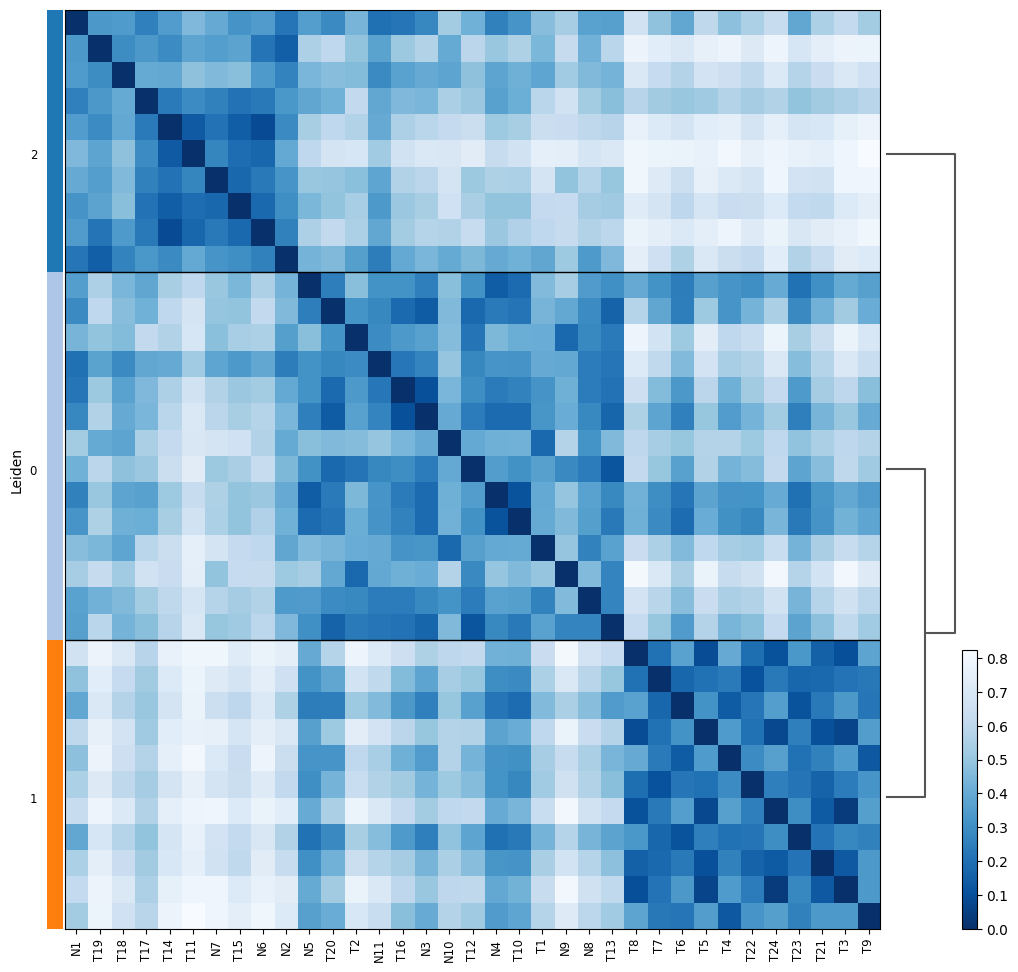

In [3]:
proportion_df=pl.pl.clustering_emd(adata, res = adata.uns['best_res'])

In [4]:
proportion_df.loc[proportion_df['Predicted_Labels'] == '0', 'Predicted_Labels'] = 'Tumor 1'
proportion_df.loc[proportion_df['Predicted_Labels'] == '1', 'Predicted_Labels'] = 'Normal'
proportion_df.loc[proportion_df['Predicted_Labels'] == '2', 'Predicted_Labels'] = 'Tumor 2'

In [15]:
from adjustText import adjust_text
from matplotlib.lines import Line2D
from matplotlib import pyplot as plt
import numpy as np
import os
import pandas as pd
from pydeseq2.dds import DeseqDataSet
from pydeseq2.ds import DeseqStats
import seaborn as sns
import anndata




def extract_cells_from_gene_expression_for_clustering(adata,sample_col,col_cell,cell_list,path_results=None,normalization=True,n_top_genes=2000,highly_variable_genes_=False):
    
    
    """
    Extract and save gene expression data for specific cells for clustering analysis.

    Parameters:
        adata : AnnData object
            An Annotated Data (AnnData) object containing gene expression data.
        sample_col : str
            The column name in the adata.obs DataFrame containing sample IDs.
        col_cell : str
            The column name in the adata.obs DataFrame containing cell type labels.
        cell_list : list
            A list of cell types for which gene expression data will be extracted and saved.
        path_results : str or None, optional (default=None)
            The path to the directory where the extracted data will be saved as CSV files.
            If None, the default path 'Results_PILOT/cells/' will be used.
        normalization : bool, optional (default=True)
            Whether to normalize the gene expression data by total count and apply log1p transformation.
        n_top_genes : int, optional (default=2000)
            The number of top highly variable genes to select. Only applicable if highly_variable_genes_ is True.
        highly_variable_genes_ : bool, optional (default=False)
            Whether to select highly variable genes for analysis.

    Returns:
        Gene exp. dataframe
    """
    for cell in cell_list:
        adata_new = adata[adata.obs[col_cell].isin([cell]),:]
        if normalization:
            sc.pp.normalize_total(adata_new, target_sum=1e4)
            sc.pp.log1p(adata_new)
        
        if highly_variable_genes_:
            
            sc.pp.highly_variable_genes(adata_new, n_top_genes=n_top_genes)
                # Access the list of highly variable genes
            highly_variable_genes = adata_new.var['highly_variable']
            df=adata_new[:,highly_variable_genes].X
            df=pd.DataFrame(df.toarray())
            highly_variable_gene_names = adata_new.var_names[np.array(adata_new.var['highly_variable'])]
            df.columns=list(highly_variable_gene_names)
        else:
            
            df=adata_new[:,adata_new.var_names].X
            df=pd.DataFrame(df.toarray())
            df.columns=adata_new.var_names
            
    
        df['sampleID']=list(adata_new.obs[sample_col])
        
        if path_results==None:
            if not os.path.exists('Results_PILOT/cells/'):
                os.makedirs('Results_PILOT/cells/')
            path_results='Results_PILOT/cells/'
        else:
            path_results=path_results

        
        df.to_csv(path_results+cell+'.csv')
        return df



def volcano_plot(scores, foldchanges, p_values, cell_type, feature1, feature2, fc_thr = 1, pv_thr = 1,
                 figsize = (20,20), output_path = None,n_p=5,n_n=5,font_size=18, marker='o',
                             color='w',
                             markersize=8,
                             font_weight_legend='normal',
                             size_legend=12,dpi=100
                 
                 
                             ):
   
    """
    Generate a volcano plot to visualize gene expression significance.

    Parameters:
        scores : pandas Series
            A pandas Series containing the expression scores for genes.
        foldchanges : array-like
            An array-like containing the fold changes for genes.
        p_values : pandas Series
            A pandas Series containing the p-values for genes.
        cell_type : str
            The name of the cell type being analyzed.
        feature1 : str
            The name of the first feature being compared.
        feature2 : str
            The name of the second feature being compared.
        fc_thr : float, optional (default=1)
            The threshold for log2FoldChange to determine significance.
        pv_thr : float, optional (default=1)
            The threshold for negative log10 of p-value to determine significance.
        figsize : tuple, optional (default=(15, 15))
            The size of the plot figure.
        output_path : str, optional (default=None)
            The path to save the output plot. If None, the plot will be displayed.
        n_p : int, optional (default=5)
            The number of labels that the user wants to show over the plot for positive threshold.
        n_n : int, optional (default=5)
            The number of labels that the user wants to show over the plot for negative threshold.
        font_size : int, optional (default=18)
            Font size for the plot.
        marker : str, optional (default='o')
            Marker style for data points in the plot.
        color : str, optional (default='w')
            Color for data points in the plot.
        markersize : int, optional (default=8)
            Marker size for data points in the plot.
        font_weight_legend : str, optional (default='normal')
            Font weight for legend text.
        size_legend : int, optional (default=12)
            Font size for legend text.
        dpi : int, optional
            Dots per inch for the saved plot image. Default is 100.

    Returns:
        None
    """

    
    
    df = pd.DataFrame(columns=['log2FoldChange', 'nlog10', 'symbol'])
    df['log2FoldChange'] = foldchanges
    df['nlog10'] = -np.log10(p_values.values)
    df['symbol'] = scores.index.values
    
    df.replace([np.inf, -np.inf], np.nan, inplace=True)
    df.dropna(subset=["nlog10"], how="all", inplace=True)
    

    selected_labels = df.loc[ (np.abs(df.log2FoldChange) >= fc_thr) & (df['nlog10'] >= pv_thr)]['symbol'].values
    group1_selected_labels = df.loc[ (df.log2FoldChange <= -fc_thr) & (df['nlog10'] >= pv_thr)]['symbol'].values
    pd.DataFrame(group1_selected_labels).to_csv(output_path + "/significant_genes_" + str(cell_type) + "_" + str(feature1) + ".csv")
    
    group2_selected_labels = df.loc[ (df.log2FoldChange >= fc_thr) & (df['nlog10'] >= pv_thr)]['symbol'].values
    pd.DataFrame(group2_selected_labels).to_csv(output_path + "/significant_genes_" + str(cell_type) + "_" + str(feature2) + ".csv")
    
    def map_shape(symbol):
        if symbol in selected_labels:
            return 'important'
        return 'not'
    
    df['color'] = df[['log2FoldChange', 'symbol', 'nlog10']].apply(pl.pl.map_color, fc_thrr = fc_thr, pv_thrr = pv_thr, axis = 1)
    df['shape'] = df.symbol.map(map_shape)
    df['baseMean'] = df.nlog10*10

    
    plt.figure(figsize = figsize, frameon=False, dpi=100)
    plt.style.use('default')
    
    
    #plt.xlim(-xlim, xlim)
    ax = sns.scatterplot(data = df, x = 'log2FoldChange', y = 'nlog10', 
                         hue = 'color', hue_order = ['no', 'very higher','higher', 'mix', 'very lower', 'lower'],
                         palette = ['lightgrey', '#d62a2b', '#D62A2B7A',
                                    'lightgrey', '#1f77b4', '#1F77B47D'],
                         style = 'shape', style_order = ['not', 'important'],
                         markers = ['o', 'o'], 
                         size = 'baseMean', sizes = (40, 800)
                        )

    ax.axhline(pv_thr, zorder = 0, c = 'k', lw = 2, ls = '--')
    ax.axvline(fc_thr, zorder = 0, c = 'k', lw = 2, ls = '--')
    ax.axvline(-fc_thr, zorder = 0, c = 'k', lw = 2, ls = '--')

    texts = []
    filtered_df = df.loc[df['nlog10'] >= pv_thr]
    print("filtered_df: ", filtered_df)
    subset_labels_fold_change_pos = filtered_df.loc[filtered_df['log2FoldChange'] >= fc_thr]
    subset_labels_fold_change_pos = subset_labels_fold_change_pos.sort_values(by='nlog10', ascending=False)
    subset_labels_fold_change_pos = subset_labels_fold_change_pos.head(n_p)['symbol'].values
    print("subset_labels_fold_change_pos: ", subset_labels_fold_change_pos)

    subset_labels_fold_change_neg = filtered_df.loc[filtered_df['log2FoldChange'] <= -fc_thr]
    subset_labels_fold_change_neg = subset_labels_fold_change_neg.sort_values(by='nlog10', ascending=False)
    subset_labels_fold_change_neg = subset_labels_fold_change_neg.head(n_n)['symbol'].values
    print("subset_labels_fold_change_neg: ", subset_labels_fold_change_neg)

    # Combine the subsets of genes
    subset_labels = np.concatenate([subset_labels_fold_change_pos, subset_labels_fold_change_neg])
    print("Subset Labels: ", subset_labels)
    print("length of df: ", len(df))
    x = 0
    y = 0
    z = 0
    for i in range(len(df)):
        if df.iloc[i].symbol in subset_labels:
            x=x+1
            print("entered first/upper if statement ", x, "times")
            if df.iloc[i].nlog10 >= pv_thr and (df.iloc[i].log2FoldChange >= fc_thr):
                y=y+1
                texts.append(plt.text(x = df.iloc[i].log2FoldChange, y = df.iloc[i].nlog10, s = df.iloc[i].symbol,
                                     fontsize = font_size, weight = 'bold', family = 'sans-serif'))
            if df.iloc[i].nlog10 >= pv_thr and ( df.iloc[i].log2FoldChange <= -fc_thr):
                z=z+1
                texts.append(plt.text(x = df.iloc[i].log2FoldChange, y = df.iloc[i].nlog10, s = df.iloc[i].symbol,
                                     fontsize = font_size, weight = 'bold', family = 'sans-serif'))
    if y>0:
        print("entred 1st 2nd level if statement ", y, "times")
    if z>0:
        print("entred 1st 2nd level if statement ", z, "times")
    print("df:", df)
    adjust_text(texts)
   # for i in range(len(df)):
    #    if df.iloc[i].symbol in subset_labels:
     #       if df.iloc[i].nlog10 >= pv_thr and (df.iloc[i].log2FoldChange >= fc_thr):
      #          texts.append(plt.text(x = df.iloc[i].log2FoldChange, y = df.iloc[i].nlog10, s = df.iloc[i].symbol,
          #                           fontsize = 16, weight = 'bold', family = 'sans-serif'))
       #     if df.iloc[i].nlog10 >= pv_thr and ( df.iloc[i].log2FoldChange <= -fc_thr):
        #        texts.append(plt.text(x = df.iloc[i].log2FoldChange, y = df.iloc[i].nlog10, s = df.iloc[i].symbol,
         #                            fontsize = 16, weight = 'bold', family = 'sans-serif'))
    #adjust_text(texts)

    custom_lines = [Line2D([0], [0], marker=marker, color=color, markerfacecolor='#d62a2b', markersize=markersize),
                   Line2D([0], [0], marker=marker, color=color, markerfacecolor='#1f77b4', markersize=markersize)]

    plt.legend(custom_lines, ['Higher expressions in ' + feature2, 'Higher expressions in ' + feature1],loc = 1,
               bbox_to_anchor = (1,1.1), frameon = False, prop = {'weight': font_weight_legend, 'size': size_legend})

    for axis in ['bottom', 'left']:
        ax.spines[axis].set_linewidth(2)

    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    ax.tick_params(width = 2)

    plt.title("Expression Score \n "+feature1+" - "+feature2, fontsize = font_size)
    plt.xticks(size = font_size, weight = 'bold')
    plt.yticks(size = font_size, weight = 'bold')
    plt.xlabel("$log_{2}$ (Fold Change)", size = font_size)
    plt.ylabel("-$log_{10}$ (P-value)", size = font_size)

#     plt.savefig(filename, dpi = 100, bbox_inches = 'tight', facecolor = 'white')
    plt.savefig(output_path + "/volcano_" + str(feature1) + "-" + str(feature2) + "_FC.pdf",
                dpi = dpi, bbox_inches = 'tight', facecolor = 'white')
    plt.show()

def compute_diff_expressions2(adata,cell_type: str = None,
                             proportions: pd.DataFrame = None,
                             selected_genes: list = None,
                             font_size:int=18,
                             group1: str = 'Tumor 1',
                             group2: str = 'Tumor 2',
                             label_name: str = 'Predicted_Labels',
                             fc_thr: float = 0.5,
                             pval_thr: float = 0.01,
                             sample_col:str='sampleID',
                             col_cell:str ='cell_types',
                             path=None,
                             normalization=False,
                             n_top_genes=2000,
                             highly_variable_genes_=True,
                             number_n=5,
                             number_p=5,
                             marker='o',
                             color='w',
                             markersize=8,
                             font_weight_legend='normal',
                             size_legend=12,
                             figsize=(15,15),dpi=100
                             ):

    """
    Using limma R package, lmFit fits a linear model using weighted least squares for each gene.
    Comparisons between groups (log fold-changes) are obtained as contrasts of these fitted linear models.
    Empirical Bayes smoothing of standard errors (shrinks standard errors
    that are much larger or smaller than those from other genes towards the average standard error).

    Parameters
    ----------
    adata : AnnData
        Annotated data matrix.
    cell_type : str, optional
        Specify cell type name to check its differential expression genes. The default is None.
    proportions : pd.DataFrame, optional
        Cell types proportions in each sample. The default is None.
    selected_genes : list, optional
        Specify gene names to be considered for checking their differentiation.
    font_size : int, optional
        Font size for plot labels and legends. The default is 18.
    group1 : str, optional
        Name of the first patient sub-group for comparison. The default is 'Tumor 1'.
    group2 : str, optional
        Name of the second patient sub-group for comparison. The default is 'Tumor 2'.
    label_name : str, optional
        Name of the column containing the labels of patient sub-groups. The default is 'Predicted_Labels'.
    fc_thr : float, optional
        Specify the fold change threshold. The default is 0.5.
    pval_thr : float, optional
        Specify the adjusted p-value threshold. The default is 0.01.
    sample_col : str, optional
        Name of the column containing sample IDs. The default is 'sampleID'.
    col_cell : str, optional
        Name of the column containing cell type annotations. The default is 'cell_types'.
    path : str, optional
        Path to save the results. The default is None.
    normalization : bool, optional
        Perform gene expression normalization. The default is False.
    n_top_genes : int, optional
        Number of top variable genes to consider. The default is 2000.
    highly_variable_genes_ : bool, optional
        Determine highly variable genes. The default is True.
    number_n : int, optional
        The number of labels that the user wants to show over the plot for negative thresholds. The default is 5.
    number_p : int, optional
        The number of labels that the user wants to show over the plot for positive thresholds. The default is 5.
    marker : str, optional
        Marker style for the labels in the volcano plot. The default is 'o'.
    color : str, optional
        Marker color for the labels in the volcano plot. The default is 'w'.
    markersize : int, optional
        Marker size for the labels in the volcano plot. The default is 8.
    font_weight_legend : str, optional
        Font weight for legend labels. The default is 'normal'.
    size_legend : int, optional
        Font size for legend labels. The default is 12.
    figsize: tuple, optional
        Figure size. The default is (15,15).
    dpi : int, optional
        Dots per inch for the saved plot image. Default is 100.

    Returns
    -------
    None

    Generates and displays a volcano plot of fold changes between two interested patient sub-groups.
    Saves a statistical table of each gene.
    Saves significantly differentiated genes in each group.
    """


    path_to_result='Results_PILOT'
    
    if os.path.exists(path_to_result + "/cells/" + cell_type + ".csv"):

        cells = pd.read_csv(path_to_result + "/cells/" + cell_type + ".csv", index_col = 0)  
   
    elif cell_type not in adata.uns:
        cells=pl.tl.extract_cells_from_gene_expression_for_clustering(adata,sample_col=sample_col,col_cell=col_cell,cell_list=[cell_type],path_results=path,normalization=normalization,n_top_genes=n_top_genes,highly_variable_genes_=highly_variable_genes_)
        #cells = pd.read_csv(path_to_result + "/cells/" + cell_type + ".csv", index_col = 0)
    
    elif cell_type in adata.uns :
         cells=adata.uns[cell_type] 
    
    
    
    import rpy2.robjects as robjects
    import rpy2.robjects.numpy2ri
    from rpy2.robjects import pandas2ri
    from rpy2.robjects.packages import importr
    pandas2ri.activate()
    
    # prepare data for R
    proportions.index = proportions['sampleID']

    ## proportions: table [sampleID     | predicted_labels]
    ##                     Patient_01   | Tumor 1
    ##                     Patient_02   | Tumor 2
    ##                     Patient_03   | Tumor 1
    ## What it does: 
        ## links every individual cell back to Patient Group it belongs to.
    ## What it means: 
        ## If Cell #105 comes from "Patient X," and PILOT previously labeled 
        ## "Patient X" as belonging to Tumor 1, this code ensures that Cell #105 
        ## is tagged as a "Tumor 1" sample for the statistical test.
    if selected_genes is None:
        selected_genes = cells.iloc[:,1:-1].columns
    data = cells[selected_genes]
    pred_labels = pd.DataFrame()
    pls = proportions.loc[cells['sampleID']]
    pred_labels['Predicted_Labels'] = pls[label_name]
    pred_labels['sampleID'] = pls['sampleID']
    
    # load R packages and data
    R=robjects.r ## create R object/"portal" in python
    R('library(limma)') 
    R.assign('data',data) ## gene expression matrix: turn pd dataframe into R df, "copy" it into R memory
    R.assign('pred_labels', pred_labels) ## same, which cell is in which group
    R.assign('selected_groups', [group1, group2]) ## two groups to compare, i.e. tumor1, tumor2
    ## filters metadata to keep ONLY cells belonging to the 2 compared groups 
    R('selected_pred_labels <- pred_labels[which(pred_labels$Predicted_Labels %in% selected_groups),]')
    ## uses those filtered labels to grab corresponding gene expression rows from main data matrix
    R('subresult <- data[row.names(selected_pred_labels),]')

    # delete for memory
    # del data
    # del pred_labels
    
    # run limma
    print('run limma lmFit')
    ## t(subresult): R expects genes in rows, samples in columns, but Python stores the other way around
        ## t() transposes matrix.
    ## as.factor(selected_pred_labels$Predicted_Labels) — Categorizing Groups
        ## selected_pred_labels$Predicted_Labels: Accesses column of labels (e.g., "Sick" vs. "Healthy")
        ## as.factor(): Converts strings into statistical Factor. R needs factors to understand that "Sick" isn't just text, but a distinct experimental group.
    ## unclass(...) — The "Matrix" Trick
        ## lmFit: requires "Design Matrix" (matrix of 0s + 1s indicating which sample belongs to which group).
        ## unclass() on a factor effectively turns those labels into their underlying numeric codes (1, 2, 3...).
    ## limma::lmFit(...) — The Linear Model
        ## Fits multiple linear regression model to every gene simultaneously
        ## Input: Your gene expression (subresult) + experimental groups (design)
        ## Process: Calculates "coefficients" (avg expression level for each label group) + residuals (noise)
        ## Output: Returns Large MArrayLM object -> contains all slopes, intercepts, errors for every gene in your study.
    R('fit <- limma::lmFit(t(subresult), design = unclass(as.factor(selected_pred_labels$Predicted_Labels)))')
    print('run limma eBayes')
    ##
    ## 
    R('fit <-  limma::eBayes(fit)')
    R('res <- limma::topTable(fit, n = 2000)')
    R('res <- res[colnames(data), ]')
    
    # get results
    res = R('''res''')
    
    if not os.path.exists(path_to_result+'/Diff_Expressions_Results/'+cell_type):
            os.makedirs(path_to_result+'/Diff_Expressions_Results/'+cell_type)
    path_to_result=path_to_result+'/Diff_Expressions_Results/'+cell_type+'/'
    res.to_csv(path_to_result + "/diff_expressions_stats_" + cell_type + ".csv")
      
    pv_thr = -np.log10(pval_thr)
    volcano_plot(cells[selected_genes].transpose(), res['logFC'], res['adj.P.Val'],
                 cell_type, group1, group2, fc_thr, pv_thr,
                 figsize = figsize, output_path = path_to_result,n_p=number_p,n_n=number_n,font_size=font_size, marker=marker,
                             color=color,
                             markersize=markersize,
                             font_weight_legend=font_weight_legend,
                             size_legend=size_legend,dpi=dpi)

def compute_diff_expressions(adata, cell_type: str = None,
                             proportions: pd.DataFrame = None,
                             selected_genes: list = None,
                             font_size: int = 18,
                             group1: str = 'Tumor 1',
                             group2: str = 'Tumor 2',
                             label_name: str = 'Predicted_Labels',
                             fc_thr: float = 0.5,
                             pval_thr: float = 0.01,
                             sample_col: str = 'sampleID',
                             col_cell: str = 'cell_types',
                             path=None,
                             normalization=False,
                             n_top_genes=2000,
                             highly_variable_genes_=True,
                             number_n=5,
                             number_p=5,
                             marker='o',
                             color='w',
                             markersize=8,
                             font_weight_legend='normal',
                             size_legend=12,
                             figsize=(15, 15), dpi=100):


    path_to_result = 'Results_PILOT'
    
    # 1. LOAD DATA
    if os.path.exists(path_to_result + "/cells/" + cell_type + ".csv"):
        cells = pd.read_csv(path_to_result + "/cells/" + cell_type + ".csv", index_col=0)  
    elif cell_type not in adata.uns:
        print("Applying method to extract cells")
        cells = extract_cells_from_gene_expression_for_clustering(
            adata, 
            sample_col=sample_col, 
            col_cell=col_cell, 
            cell_list=[cell_type], 
            path_results=path, 
            normalization=normalization, 
            n_top_genes=n_top_genes, 
            highly_variable_genes_=highly_variable_genes_
        )
    elif cell_type in adata.uns:
        cells = adata.uns[cell_type] 

    proportions.index = proportions[sample_col]

    # 2. PREPARE COUNTS & PRED_LABELS
    if selected_genes is None:
        selected_genes = cells.iloc[:, 1:-1].columns
    
    # PyDESeq2 needs raw counts (integers)
    subresult = cells[selected_genes].astype(int)
    
    # Prepare the metadata (pred_labels)
    pls = proportions.loc[cells[sample_col]]
    
    pred_labels = pd.DataFrame(index=subresult.index)
    pred_labels['Predicted_Labels'] = pls[label_name].values
    pred_labels[sample_col] = pls[sample_col]
    
    # 3. RUN PYDESEQ2
    print(f'Running PyDESeq2 for {cell_type}...')
    dds = DeseqDataSet(
        counts=subresult,
        metadata=pred_labels,
        design_factors="Predicted_Labels"
    )
    dds.deseq2()
    
    # Contrast: [Column, Numerator (Group2), Denominator (Group1)]
    stat_res = DeseqStats(dds, contrast=["Predicted_Labels", group2, group1])
    stat_res.summary()
    res = stat_res.results_df
    
    # Rename columns to match your original volcano_plot expectations
    res = res.rename(columns={'log2FoldChange': 'logFC', 'padj': 'adj.P.Val'})
    
    # 4. SAVE & PLOT
    if not os.path.exists(path_to_result + '/Diff_Expressions_Results/' + cell_type):
        os.makedirs(path_to_result + '/Diff_Expressions_Results/' + cell_type)
    
    save_path = path_to_result + '/Diff_Expressions_Results/' + cell_type + '/'
    res.to_csv(save_path + "diff_expressions_stats_" + cell_type + ".csv")
      
    pv_thr_val = -np.log10(pval_thr)
    volcano_plot(subresult.transpose(), res['logFC'], res['adj.P.Val'],
                 cell_type, group1, group2, fc_thr, pv_thr_val,
                 figsize=figsize, output_path=save_path, n_p=number_p, n_n=number_n, 
                 font_size=font_size, marker=marker, color=color, markersize=markersize,
                 font_weight_legend=font_weight_legend, size_legend=size_legend, dpi=dpi)

In [ ]:
adata.uns["Ductal cell type 1"]

In [9]:
proportion_df

,Fibroblast cell,Stellate cell,Macrophage cell,Endothelial cell,T cell,B cell,Ductal cell type 2,Endocrine cell,Ductal cell type 1,Acinar cell,Predicted_Labels,sampleID
N1,0.106625,0.046408,0.028343,0.187387,0.003192,0.000003,0.001076,0.007439,0.602166,0.017359,Tumor 2,N1
N10,0.003256,0.011029,0.012972,0.168502,0.000008,0.000006,0.000025,0.003241,0.643491,0.157470,Tumor 1,N10
N11,0.028233,0.010143,0.041976,0.565064,0.000009,0.000007,0.002922,0.001449,0.319083,0.031115,Tumor 1,N11
N2,0.086272,0.027572,0.054113,0.161817,0.003579,0.000005,0.000020,0.016334,0.384869,0.265418,Tumor 2,N2
N3,0.035202,0.162609,0.070341,0.248312,0.024191,0.000020,0.000086,0.057123,0.386722,0.015394,Tumor 1,N3
N4,0.026713,0.017470,0.000020,0.207382,0.000012,0.000009,0.001067,0.007188,0.740131,0.000008,Tumor 1,N4
N5,0.009044,0.029328,0.003403,0.227718,0.001141,0.000010,0.000044,0.007892,0.702250,0.019170,Tumor 1,N5
N6,0.111423,0.071038,0.009773,0.459526,0.005586,0.000013,0.001447,0.008357,0.325865,0.006972,Tumor 2,N6
N7,0.017955,0.040369,0.006294,0.184749,0.001804,0.000008,0.000932,0.059184,0.648346,0.040358,Tumor 2,N7
N8,0.117214,0.088526,0.082789,0.294240,0.006566,0.000827,0.000852,0.035242,0.308995,0.064750,Tumor 1,N8


run limma lmFit
run limma eBayes
filtered_df:             log2FoldChange     nlog10     symbol color shape    baseMean
CRP             -0.026818   4.681656        CRP   mix   not   46.816557
REG3A           -0.052227  15.999457      REG3A   mix   not  159.994568
SPINK1          -0.059923  16.263674     SPINK1   mix   not  162.636742
LCN2            -0.067546  24.825290       LCN2   mix   not  248.252897
LYZ             -0.068453  24.387956        LYZ   mix   not  243.879563
...                   ...        ...        ...   ...   ...         ...
NMUR2           -0.014321  13.722803      NMUR2   mix   not  137.228025
CCAT1           -0.012745  13.045660      CCAT1   mix   not  130.456595
AKR1C4          -0.011375   6.197402     AKR1C4   mix   not   61.974024
GAL             -0.013594   9.432532        GAL   mix   not   94.325324
LINC00944       -0.014227  11.670487  LINC00944   mix   not  116.704870

[1494 rows x 6 columns]
subset_labels_fold_change_pos:  []
subset_labels_fold_change_neg

IndexError: list index out of range

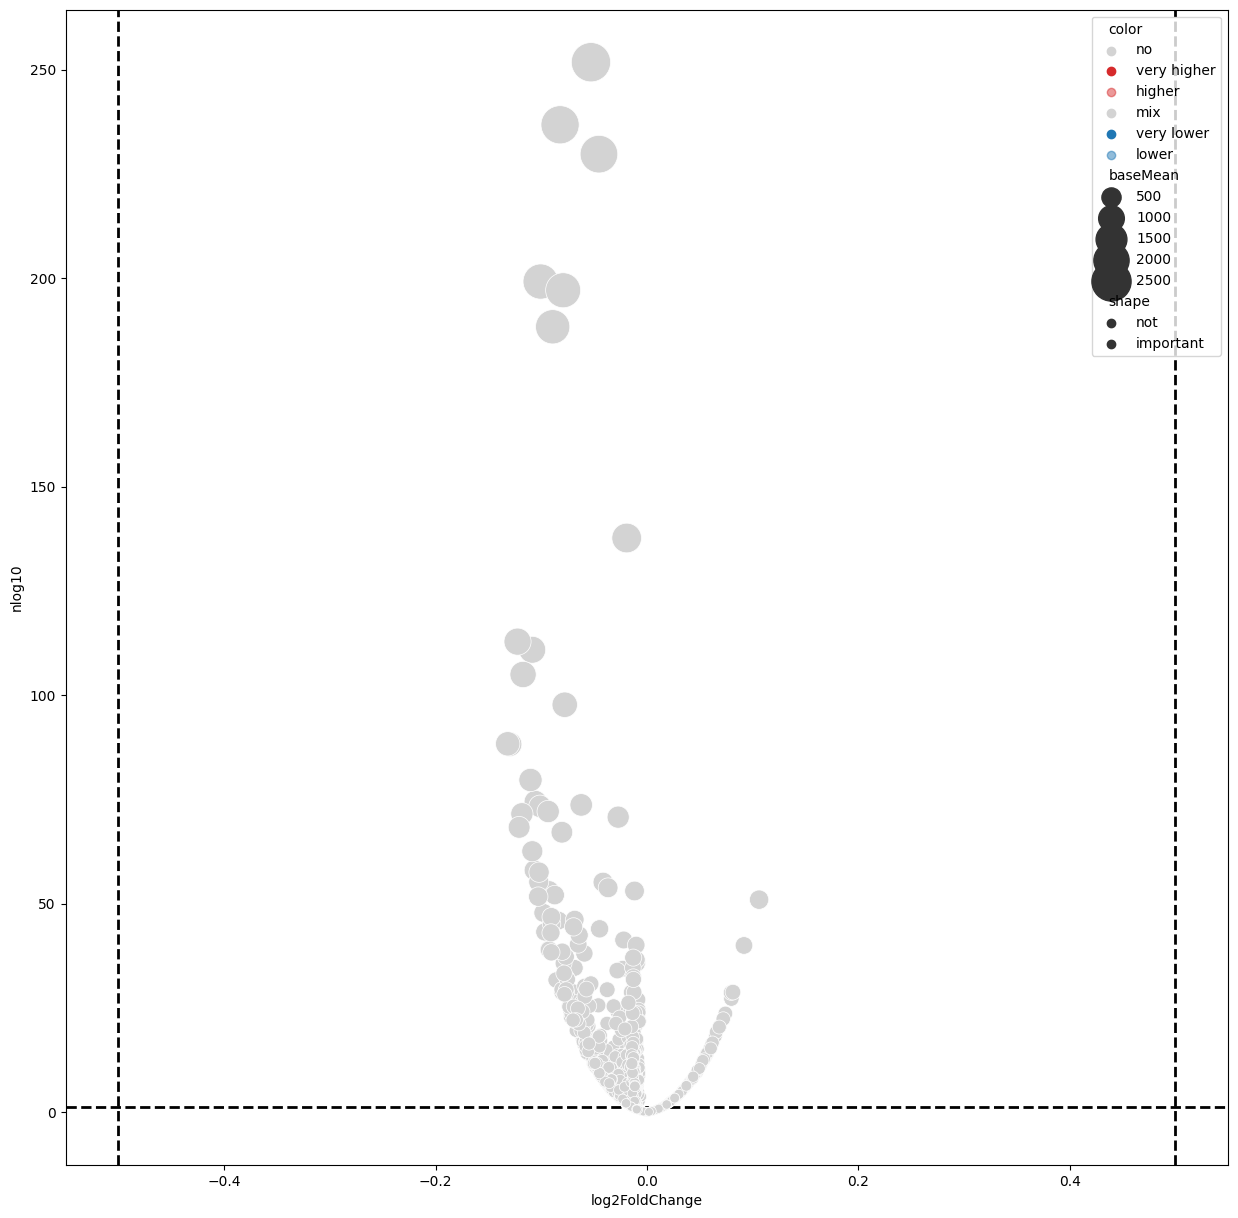

In [16]:
cell_type = "Ductal cell type 1" #look at the Cells folder
compute_diff_expressions2(
    adata,
    cell_type,
    proportion_df,
    fc_thr =  0.5,
    pval_thr = 0.05,
    group1 = 'Tumor 1', 
    group2 = 'Tumor 2',
    sample_col = 'sampleID',
    col_cell = 'cell_types',
    )

In [ ]:
import pandas as pd
import numpy as np
from pydeseq2.dds import DeseqDataSet
from pydeseq2.ds import DeseqStats

def run_pydeseq2_analysis(counts_df, metadata_df, group1, group2, label_col='Predicted_Labels'):
    """
    counts_df: pd.DataFrame (samples x genes) - RAW INTEGER COUNTS
    metadata_df: pd.DataFrame (samples x metadata)
    """
    
    # 1. Initialize DeseqDataSet
    # Ensure counts are integers
    dds = DeseqDataSet(
        counts=counts_df,
        metadata=metadata_df,
        design_factors=label_col,
        refit_cooks=True,
        n_cpus=4
    )
    
    # 2. Run the DESeq2 pipeline (normalization, dispersion, LFC fitting)
    dds.deseq2()
    
    # 3. Perform statistical testing
    # contrast: [column, target_level, reference_level]
    ds = DeseqStats(dds, contrast=[label_col, group1, group2], n_cpus=4)
    ds.summary()
    
    # 4. Extract results as DataFrame
    res = ds.results_df
    return res


